## Data Analysis

Data analysis uncovers patterns, relationships, and problems in the data before modeling.

### 1.1 Feature Distributions

<Axes: xlabel='loan_intent'>

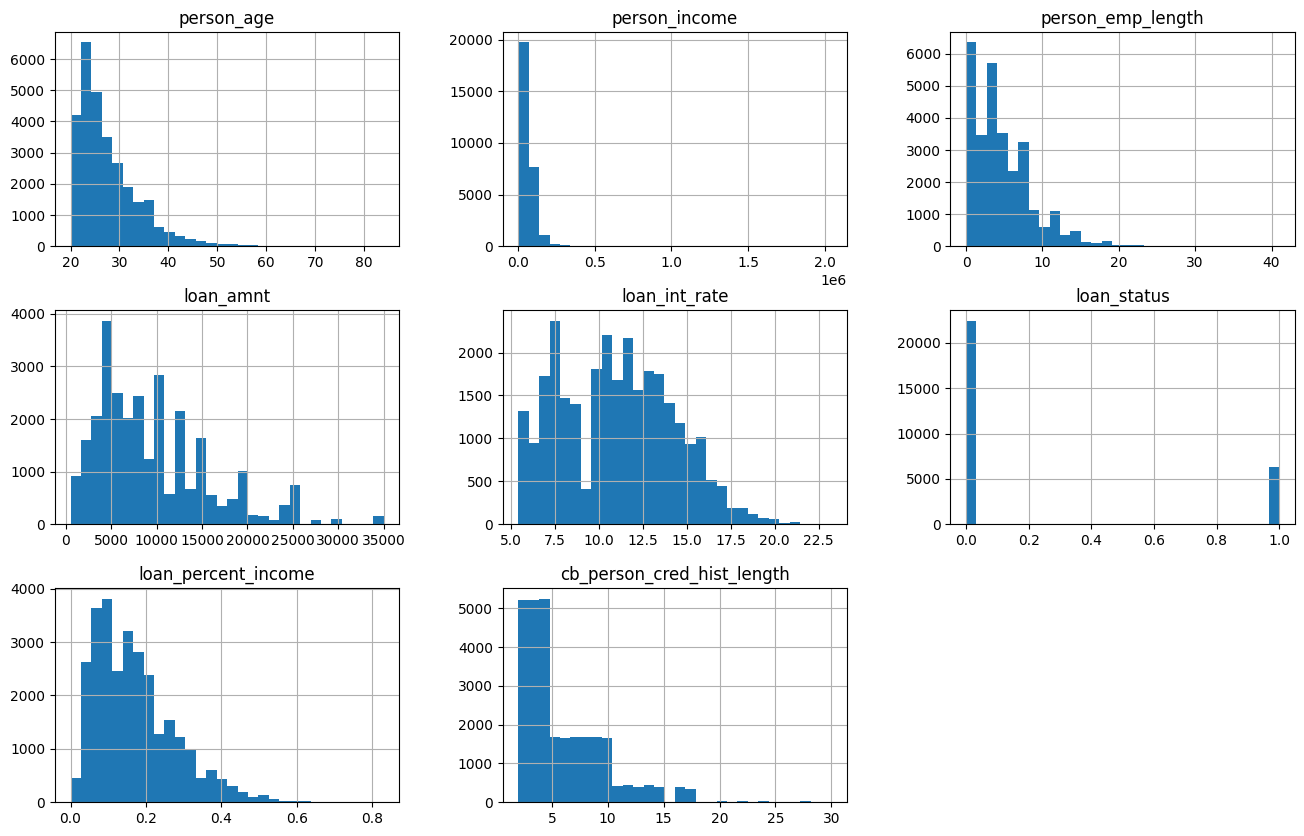

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../data/credit_risk_dataset_cleaned.csv")

df.hist(figsize=(16, 10), bins=30)
df["loan_intent"].value_counts().plot(kind="bar")

### 1.2 Correlation Analysis

<Axes: >

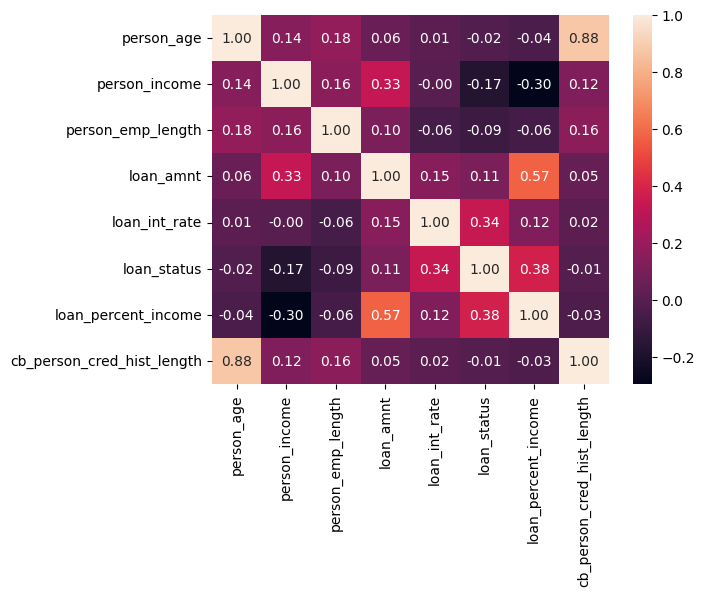

In [7]:
df.corr(numeric_only=True)["loan_status"].sort_values()
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")

### 1.3 Target variable proportion

<Axes: xlabel='loan_status', ylabel='count'>

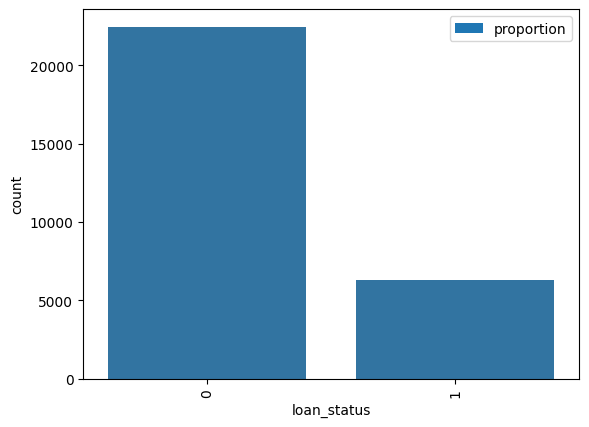

In [ ]:
df["loan_status"].value_counts(normalize=True).plot(kind="bar")
sns.countplot(x="loan_status", data=df)

### 1.4 Categorical value counts

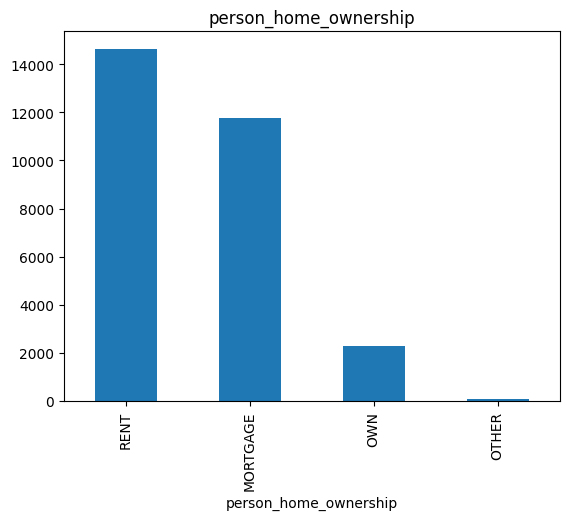

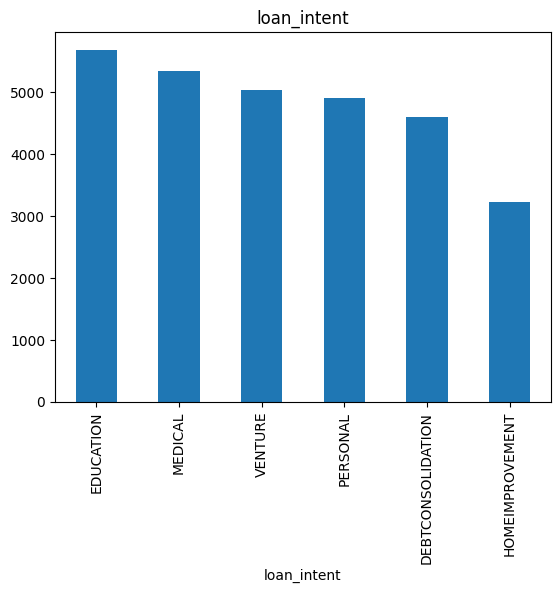

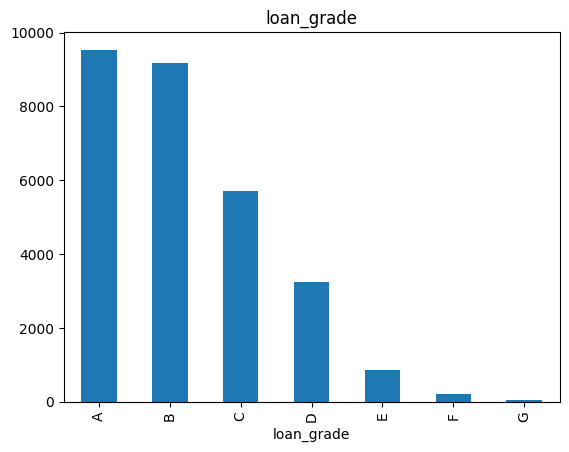

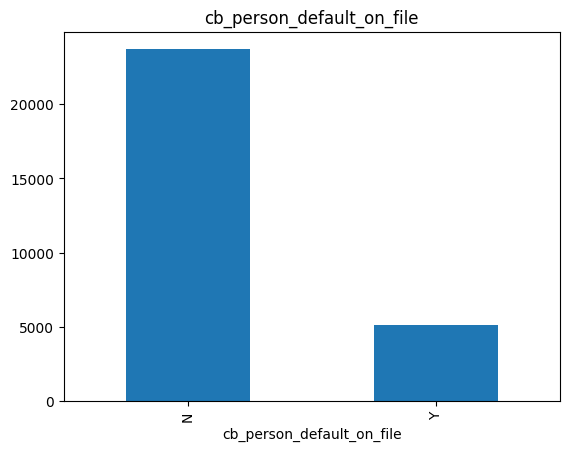

In [ ]:
for col in ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]:
    df[col].value_counts().plot(kind="bar", title=col)
    plt.show()

### 1.5 Bivariate analysis (feature vs target)

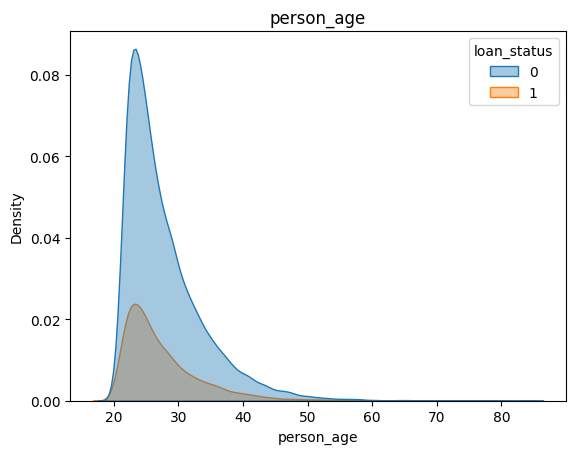

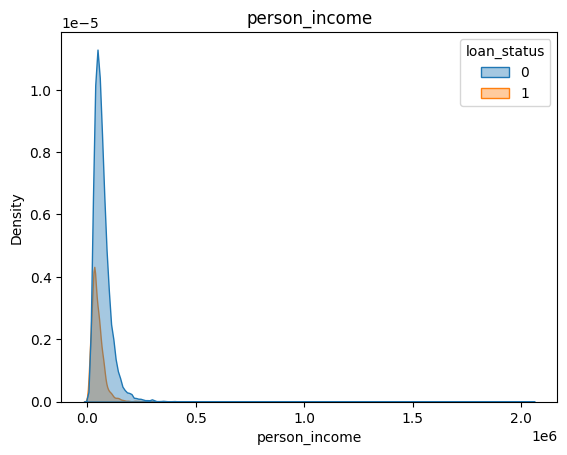

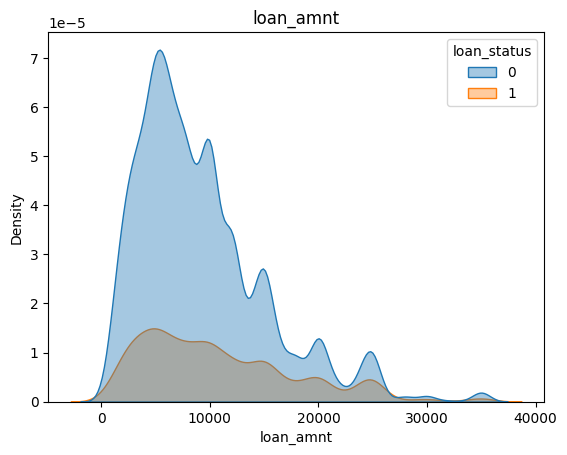

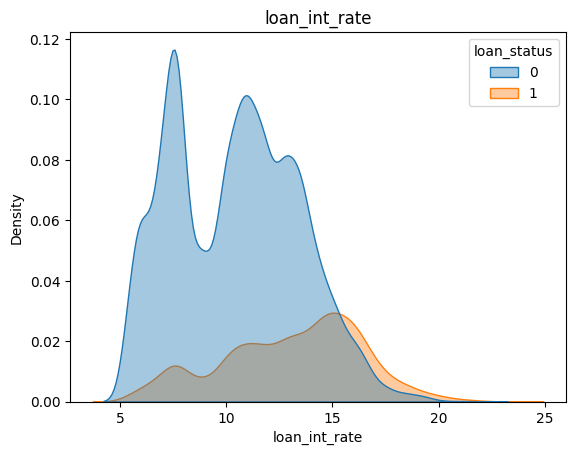

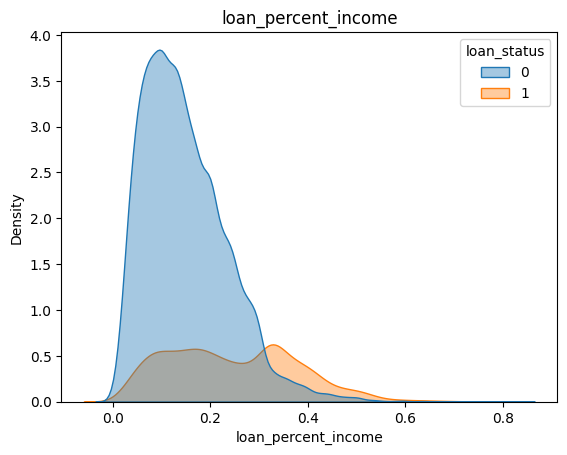

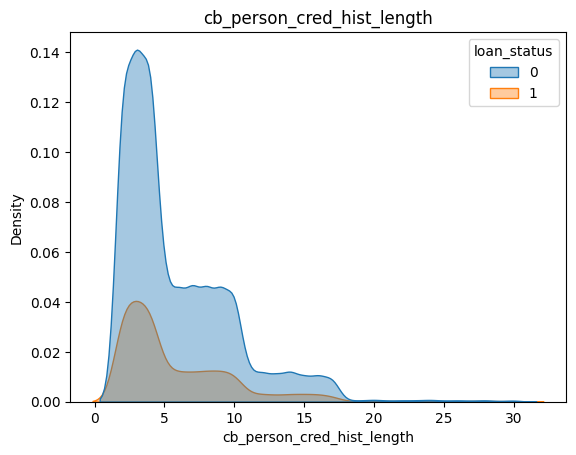

In [15]:
# KDE plot per class — shows where distributions overlap and diverge
for col in cols:
    sns.kdeplot(data=df, x=col, hue="loan_status", fill=True, alpha=0.4)
    plt.title(col)
    plt.show()

### 1.6 Correlation analysis

<Axes: title={'center': 'Correlation with loan_status'}>

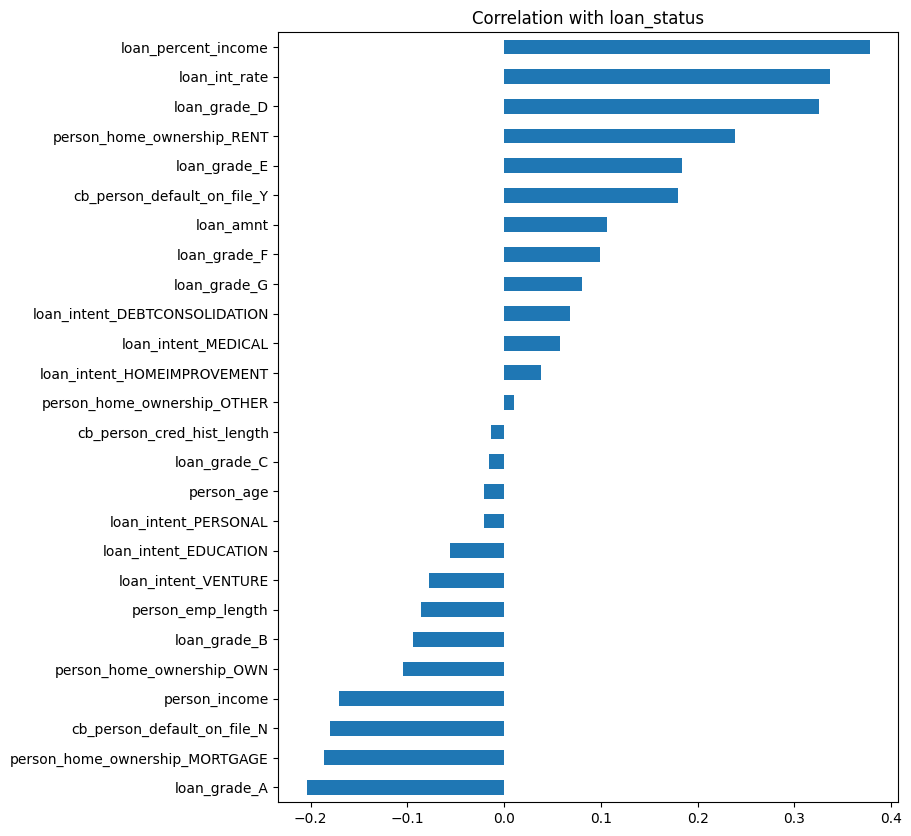

In [16]:
df_encoded = pd.get_dummies(df, columns=["person_home_ownership", "loan_intent",
                                          "loan_grade", "cb_person_default_on_file"])

# Correlation with target only — cleaner than the full heatmap
corr_target = (df_encoded.corr(numeric_only=True)["loan_status"]
                          .drop("loan_status")
                          .sort_values())

corr_target.plot(kind="barh", figsize=(8, 10), title="Correlation with loan_status")

### 1.7 Outlier visualization

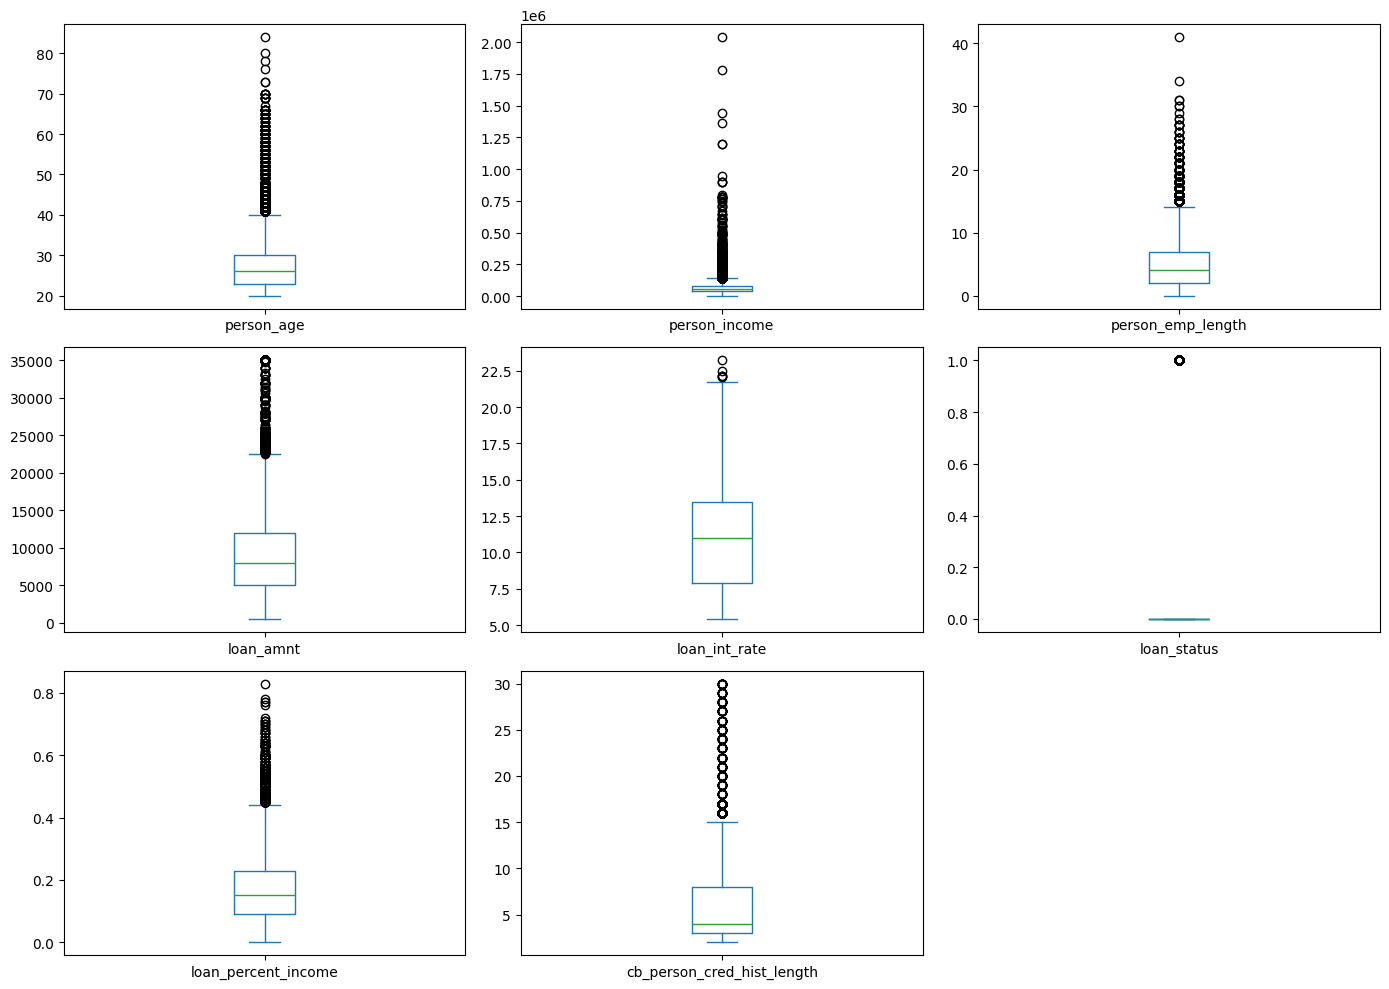

In [19]:
# Box plots for all numerics at once
df.select_dtypes("number").plot(
    kind="box", subplots=True, layout=(3, 3),
    figsize=(14, 10), sharex=False, sharey=False
)
plt.tight_layout()